The workflow here is:

```text
saved WILL .npz burst
→ load dynamic spectrum and simulation truth
→ fit a simple FLITS scattered-pulse model
→ compute FLITS residual diagnostics
→ compute independent ACF/peak-complexity metrics
→ compare similar-timescale bursts with different peak complexity
```

### Useful parameters: 

- `acf_sigma_ms`: characteristic timescale from the ACF.
- `peak_count`: number of resolved peaks in the saved 1D profile.
- `peak_rate_per_ms`: detected peak density.
- `sep_cv`: regularity/clustering of peak separations.
- `flits_profile_chi2_red`, `flits_profile_r_squared`, `flits_profile_resid_rms`: how well a single-component FLITS temporal model describes the burst envelope.
- `flits_profile_quality_flag`: profile-only quality flag.
  

## 1. Imports and setup

In [2]:
from pathlib import Path
import json
import inspect
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares, curve_fit
from scipy.signal import correlate, find_peaks, peak_widths

BURST_DIR = Path("will_flits_microshot_package/will_microshot_outputs/npz/")   # change this if needed
OUT_DIR = Path("flits_direct_results_2")
OUT_DIR.mkdir(exist_ok=True, parents=True)

DM_DEFAULT = 220.0       
TAU_ALPHA = 4.4          
FIT_DM = False           
MAX_N_BURSTS = None      

FLITS_MODEL_DM_MODE = "dedispersed"   

FLITS_FREQ_UNIT_MODE = "auto"         # "auto", "GHz", or "MHz"

FLITS_FIT_DOMAIN = "profile"          # "profile" or "dynamic_spectrum"

NORMALISE_FIT_DATA = True

# The saved simulations are long windows (~hundreds of ms), while the burst is usually
# only a few ms. I fit only a short window around the burst so FLITS cannot use the
# whole observation duration as an artificial scattering time.
FIT_CROP_PRE_MARGIN_MS = 2.0
FIT_CROP_POST_MARGIN_MS = 4.0
FIT_MIN_WINDOW_MS = 2.0
FIT_MAX_WINDOW_MS = 25.0

# Keep the single-component FLITS model physically local.  The upper bounds are also
# clipped to the fitted crop duration inside the fitting function.
FLITS_WIDTH_MIN_MS = 0.005
FLITS_WIDTH_MAX_MS = 5.0
FLITS_TAU_MIN_MS = 1e-6
FLITS_TAU_MAX_MS = 5.0

PROFILE_R2_PASS = 0.50
PROFILE_CHI2_PASS = 5.0

PEAK_SIGMA_THRESHOLD = 5.0
MIN_PEAK_DISTANCE_MS = 0.04
ACF_FIT_MAX_LAG_MS = 2.5

print("BURST_DIR =", BURST_DIR.resolve())
print("OUT_DIR   =", OUT_DIR.resolve())
print("FLITS_MODEL_DM_MODE =", FLITS_MODEL_DM_MODE)
print("FLITS_FREQ_UNIT_MODE =", FLITS_FREQ_UNIT_MODE)
print("FLITS_FIT_DOMAIN =", FLITS_FIT_DOMAIN)
print("FIT_CROP_PRE_MARGIN_MS/POST =", FIT_CROP_PRE_MARGIN_MS, FIT_CROP_POST_MARGIN_MS)
print("FLITS width/tau max [ms] =", FLITS_WIDTH_MAX_MS, FLITS_TAU_MAX_MS)


BURST_DIR = /home/giannis/Astrovaria/will_flits_microshot_package/will_microshot_outputs/npz
OUT_DIR   = /home/giannis/Astrovaria/flits_direct_results_2
FLITS_MODEL_DM_MODE = dedispersed
FLITS_FREQ_UNIT_MODE = auto
FLITS_FIT_DOMAIN = profile
FIT_CROP_PRE_MARGIN_MS/POST = 2.0 4.0
FLITS width/tau max [ms] = 5.0 5.0


## 2. Check the actual FLITS installation

This cell should print the FLITS path and confirm that the functions/classes exist. 

In [3]:
try:
    import flits
    from flits.models import FRBModel
    from flits.params import FRBParams
    from flits.fitting import analyze_residuals
    FLITS_AVAILABLE = True
except Exception as e:
    FLITS_AVAILABLE = False
    print("FLITS import failed:", repr(e))
    raise

print("FLITS path:", flits.__file__)
print("FRBParams signature:", inspect.signature(FRBParams))
print("FRBModel signature:", inspect.signature(FRBModel))

if hasattr(FRBModel, "simulate"):
    print("FRBModel.simulate signature:", inspect.signature(FRBModel.simulate))
else:
    print("WARNING: this FRBModel has no .simulate method; inspect its methods below.")
    print([x for x in dir(FRBModel) if not x.startswith("_")])

FLITS path: /home/giannis/dsa110-FLITS/flits/__init__.py
FRBParams signature: (dm: float, amplitude: float, t0: float = 0.0, width: float = 1.0, tau_1ghz: float = 0.0, tau_alpha: float = 4.4) -> None
FRBModel signature: (params: 'FRBParams')
FRBModel.simulate signature: (self, t: 'NDArray[np.floating]', freqs: 'NDArray[np.floating]', *, tau_1ghz_override: 'float | None' = None, tau_alpha_override: 'float | None' = None, ref_freq_mhz: 'float' = 1000.0) -> 'NDArray[np.floating]'


## 3. Utility functions: loading, normalization, ACF, and peak metrics

These metrics are independent of FLITS. They quantify the morphology of the dedispersed 1D profile.

In [4]:
def scalar_from_npz(data, key, default=np.nan):
    """Read scalar values from npz containers."""
    if key not in data:
        return default
    value = data[key]
    arr = np.asarray(value)
    if arr.shape == ():
        return arr.item()
    if arr.size == 1:
        return arr.reshape(-1)[0].item()
    return value


def robust_sigma(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if not np.isfinite(mad) or mad <= 0:
        std = np.nanstd(x)
        return float(std if np.isfinite(std) and std > 0 else 1.0)
    return float(1.4826 * mad)


def estimate_offpulse_1d(profile, edge_fraction=0.20):
    p = np.asarray(profile, dtype=float)
    n = p.size
    edge = max(1, int(edge_fraction * n))
    return np.r_[p[:edge], p[-edge:]]


def normalise_profile(profile):
    p = np.asarray(profile, dtype=float)
    off = estimate_offpulse_1d(p)
    mu = np.nanmedian(off)
    sig = robust_sigma(off)
    return (p - mu) / sig


def baseline_subtract_dynamic_spectrum(ds_tf, edge_fraction=0.20):
    """
    Baseline-subtract each frequency channel.
    Input shape must be (time, frequency).
    """
    ds = np.asarray(ds_tf, dtype=float)
    nt, nf = ds.shape
    edge = max(1, int(edge_fraction * nt))
    off = np.r_[ds[:edge, :], ds[-edge:, :]]
    baseline = np.nanmedian(off, axis=0)
    noise = 1.4826 * np.nanmedian(np.abs(off - baseline[None, :]), axis=0)
    noise[~np.isfinite(noise) | (noise <= 0)] = np.nanmedian(noise[np.isfinite(noise) & (noise > 0)])
    if not np.all(np.isfinite(noise)):
        noise = np.ones(nf)
    return ds - baseline[None, :], noise


def positive_part(profile):
    p = np.asarray(profile, dtype=float)
    return np.clip(p - np.nanmedian(p), 0, None)


def t90_width_ms(profile, tsamp_ms):
    y = positive_part(profile)
    total = np.nansum(y)
    if total <= 0:
        return np.nan
    cdf = np.cumsum(y) / total
    i5 = int(np.searchsorted(cdf, 0.05))
    i95 = int(np.searchsorted(cdf, 0.95))
    return float((i95 - i5) * tsamp_ms)


def gaussian_no_offset(x, amp, sigma):
    return amp * np.exp(-0.5 * (x / sigma) ** 2)


def acf_metrics(profile, tsamp_ms, fit_max_lag_ms=2.5):
    """Return ACF central-width and residual metrics."""
    p = normalise_profile(profile)
    p = p - np.nanmean(p)
    acf = correlate(p, p, mode="full", method="auto")
    lags = np.arange(-p.size + 1, p.size) * tsamp_ms
    if np.nanmax(np.abs(acf)) > 0:
        acf = acf / np.nanmax(acf)

    mask = (np.abs(lags) <= fit_max_lag_ms) & np.isfinite(acf)
    sigma = np.nan
    resid_rms = np.nan
    try:
        popt, _ = curve_fit(
            gaussian_no_offset,
            lags[mask],
            acf[mask],
            p0=[1.0, 0.15],
            bounds=([0.0, tsamp_ms / 5], [2.0, fit_max_lag_ms]),
            maxfev=20000,
        )
        model = gaussian_no_offset(lags[mask], *popt)
        sigma = float(abs(popt[1]))
        resid_rms = float(np.sqrt(np.nanmean((acf[mask] - model) ** 2)))
    except Exception:
        pass

    return {
        "acf_sigma_ms": sigma,
        "acf_resid_rms": resid_rms,
    }


def peak_complexity_metrics(profile, tsamp_ms, sigma_threshold=5.0, min_peak_distance_ms=0.04):
    """Peak-count and spacing metrics for a 1D dedispersed profile."""
    p = normalise_profile(profile)
    distance = max(1, int(round(min_peak_distance_ms / tsamp_ms)))
    peaks, props = find_peaks(p, height=sigma_threshold, distance=distance)
    heights = props.get("peak_heights", np.array([]))

    if len(peaks) >= 2:
        seps_ms = np.diff(peaks) * tsamp_ms
        sep_mean = float(np.nanmean(seps_ms))
        sep_std = float(np.nanstd(seps_ms))
        sep_cv = float(sep_std / sep_mean) if sep_mean > 0 else np.nan
    else:
        sep_mean = np.nan
        sep_std = np.nan
        sep_cv = np.nan

    widths_ms = np.array([])
    try:
        if len(peaks) > 0:
            widths_samples = peak_widths(p, peaks, rel_height=0.5)[0]
            widths_ms = widths_samples * tsamp_ms
    except Exception:
        pass

    # Normalized entropy of peak heights; high means the peak energy is distributed more evenly.
    if len(heights) > 1 and np.nansum(heights) > 0:
        q = heights / np.nansum(heights)
        amplitude_entropy = float(-np.nansum(q * np.log(q)) / np.log(len(q)))
    elif len(heights) == 1:
        amplitude_entropy = 0.0
    else:
        amplitude_entropy = np.nan

    burst_t90 = t90_width_ms(p, tsamp_ms)
    peak_rate = float(len(peaks) / burst_t90) if np.isfinite(burst_t90) and burst_t90 > 0 else np.nan

    return {
        "peak_count": int(len(peaks)),
        "peak_rate_per_ms": peak_rate,
        "sep_mean_ms": sep_mean,
        "sep_std_ms": sep_std,
        "sep_cv": sep_cv,
        "peak_width_median_ms": float(np.nanmedian(widths_ms)) if widths_ms.size else np.nan,
        "peak_height_max": float(np.nanmax(heights)) if len(heights) else np.nan,
        "amplitude_entropy": amplitude_entropy,
        "t90_ms": burst_t90,
    }


def profile_metrics(profile, tsamp_ms, burst_id="burst"):
    out = {"burst_id": burst_id, "tsamp_ms": float(tsamp_ms)}
    out.update(acf_metrics(profile, tsamp_ms, fit_max_lag_ms=ACF_FIT_MAX_LAG_MS))
    out.update(peak_complexity_metrics(
        profile,
        tsamp_ms,
        sigma_threshold=PEAK_SIGMA_THRESHOLD,
        min_peak_distance_ms=MIN_PEAK_DISTANCE_MS,
    ))
    return out

## 4. Load `.npz` bursts

The previous WILL notebook saved files with keys like:

```text
burst_id, t_ms, dynamic_spectrum, profile, shot_times_ms, amplitudes,
center_freqs_mhz, chan_freqs_mhz, tsamp_ms, dm, used_will, will_method
```

This loader is intentionally permissive, so it should also work if you renamed a few keys.

In [5]:
def find_burst_files():
    global BURST_DIR
    if BURST_DIR.exists():
        files = sorted(BURST_DIR.glob("*.npz"))
    else:
        files = []

    if not files:
        for candidate in AUTO_DIR_CANDIDATES:
            if candidate.exists():
                files = sorted(candidate.glob("*.npz"))
                if files:
                    BURST_DIR = candidate
                    break

    if MAX_N_BURSTS is not None:
        files = files[:MAX_N_BURSTS]

    return files


def load_burst_npz(path):
    """
    Load a saved WILL burst. Returns a dict containing:
    - ds_tf: dynamic spectrum shaped (time, frequency)
    - profile: 1D profile
    - t_ms: time axis in ms
    - freqs_mhz: frequency axis in MHz
    - dm: DM in pc cm^-3
    - truth metadata if available
    """
    path = Path(path)
    data = np.load(path, allow_pickle=True)
    keys = set(data.files)

    burst_id = str(scalar_from_npz(data, "burst_id", path.stem))
    tsamp_ms = float(scalar_from_npz(data, "tsamp_ms", np.nan))
    dm = float(scalar_from_npz(data, "dm", DM_DEFAULT))

    # Dynamic spectrum
    ds = None
    for key in ["dynamic_spectrum", "ds", "data", "I"]:
        if key in keys:
            ds = np.asarray(data[key], dtype=float)
            break
    if ds is None:
        raise KeyError(f"No dynamic spectrum key found in {path}; keys={sorted(keys)}")
    if ds.ndim != 2:
        raise ValueError(f"Dynamic spectrum must be 2D, got shape {ds.shape} in {path}")

    # Profile
    profile = None
    for key in ["profile", "dedispersed_profile", "time_series"]:
        if key in keys:
            profile = np.asarray(data[key], dtype=float)
            break

    # Frequencies
    freqs = None
    for key in ["chan_freqs_mhz", "freqs_mhz", "frequencies_mhz", "freqs"]:
        if key in keys:
            freqs = np.asarray(data[key], dtype=float)
            break

    # Time axis
    t_ms = None
    for key in ["t_ms", "time_ms", "times_ms"]:
        if key in keys:
            t_ms = np.asarray(data[key], dtype=float)
            break

    # Infer axis order from profile/time/frequency lengths.
    if profile is not None:
        if ds.shape[0] == profile.size:
            ds_tf = ds
        elif ds.shape[1] == profile.size:
            ds_tf = ds.T
        else:
            ds_tf = ds
    elif t_ms is not None:
        if ds.shape[0] == t_ms.size:
            ds_tf = ds
        elif ds.shape[1] == t_ms.size:
            ds_tf = ds.T
        else:
            ds_tf = ds
    elif freqs is not None:
        if ds.shape[1] == freqs.size:
            ds_tf = ds
        elif ds.shape[0] == freqs.size:
            ds_tf = ds.T
        else:
            ds_tf = ds
    else:
        ds_tf = ds

    nt, nf = ds_tf.shape

    if not np.isfinite(tsamp_ms):
        if t_ms is not None and t_ms.size > 1:
            tsamp_ms = float(np.nanmedian(np.diff(t_ms)))
        else:
            raise ValueError(f"No tsamp_ms or usable t_ms found in {path}")

    if t_ms is None or t_ms.size != nt:
        t_ms = np.arange(nt) * tsamp_ms

    if freqs is None or freqs.size != nf:
        # Reasonable default for the previous simulation notebook.
        freqs = np.linspace(1800.0, 1100.0, nf)

    if profile is None or profile.size != nt:
        profile = np.nanmean(ds_tf, axis=1)

    truth = {}
    for key in ["shot_times_ms", "amplitudes", "center_freqs_mhz", "used_will", "will_method"]:
        if key in keys:
            truth[key] = data[key]

    if "shot_times_ms" in truth:
        truth["input_n_peaks"] = int(np.asarray(truth["shot_times_ms"]).size)

    return {
        "path": path,
        "burst_id": burst_id,
        "tsamp_ms": tsamp_ms,
        "dm": dm,
        "ds_tf": ds_tf,
        "profile": profile,
        "t_ms": t_ms,
        "freqs_mhz": freqs,
        "truth": truth,
        "keys": sorted(keys),
    }


burst_files = find_burst_files()
print(f"Found {len(burst_files)} .npz files in {BURST_DIR.resolve()}")
for p in burst_files[:5]:
    print(" -", p)

if not burst_files:
    print("No files found. Set BURST_DIR to your folder containing saved .npz bursts and rerun this cell.")

Found 26 .npz files in /home/giannis/Astrovaria/will_flits_microshot_package/will_microshot_outputs/npz
 - will_flits_microshot_package/will_microshot_outputs/npz/clustered_n03_r02.npz
 - will_flits_microshot_package/will_microshot_outputs/npz/clustered_n03_r04.npz
 - will_flits_microshot_package/will_microshot_outputs/npz/clustered_n03_r05.npz
 - will_flits_microshot_package/will_microshot_outputs/npz/clustered_n06_r02.npz
 - will_flits_microshot_package/will_microshot_outputs/npz/clustered_n06_r03.npz


## 5. FLITS model wrapper and cropped single-burst fit

This version crops around the burst before fitting, constrains the FLITS width/scattering timescale, and keeps the model DM at zero for dedispersed cutouts.

In [6]:

def choose_model_dm(burst):
    """Choose the DM actually passed to the FLITS forward model."""
    physical_dm = float(burst.get("dm", DM_DEFAULT))
    if str(FLITS_MODEL_DM_MODE).lower() in {"dedispersed", "zero", "aligned"}:
        return 0.0
    if str(FLITS_MODEL_DM_MODE).lower() in {"physical", "raw", "dispersed"}:
        return physical_dm
    raise ValueError("FLITS_MODEL_DM_MODE must be 'dedispersed' or 'physical'")


def frequency_candidates_for_flits(freqs_mhz):
    """
    Return candidate frequency axes to try in FLITS.

    Many FRB codes store frequencies in MHz, while the DSA scattering kernel
    historically documents GHz. Because your installed wrapper may differ,
    the safe behaviour is to try the likely convention first and optionally
    fall back to the other one.
    """
    freqs_mhz = np.asarray(freqs_mhz, dtype=float)
    med = np.nanmedian(np.abs(freqs_mhz))
    mode = str(FLITS_FREQ_UNIT_MODE).lower()

    if mode == "ghz":
        return [("GHz", freqs_mhz / 1000.0 if med > 100 else freqs_mhz)]
    if mode == "mhz":
        return [("MHz", freqs_mhz)]
    if mode != "auto":
        raise ValueError("FLITS_FREQ_UNIT_MODE must be 'auto', 'GHz', or 'MHz'")

    if med > 100:
        # Try GHz first because the public DSA scattering kernel documents GHz.
        return [("GHz", freqs_mhz / 1000.0), ("MHz", freqs_mhz)]
    return [("GHz", freqs_mhz), ("MHz_like", freqs_mhz * 1000.0)]


def sort_frequency_axis_for_flits(data_tf, freqs_mhz, flits_freqs):
    """
    Sort frequencies into ascending order, as required by some FLITS kernels.
    Input data shape is (time, frequency). Returns data_ft with shape (freq, time).
    """
    freqs_mhz = np.asarray(freqs_mhz, dtype=float)
    flits_freqs = np.asarray(flits_freqs, dtype=float)
    order = np.argsort(flits_freqs)
    return data_tf[:, order].T, freqs_mhz[order], flits_freqs[order]


def burst_window_from_profile(profile, t_ms, tsamp_ms):
    """
    Find a short fitting window around the burst.

    The full saved npz files can be hundreds of ms long, but the burst emission is
    usually only a few ms.  This function estimates the burst window from positive
    fluence and then adds configurable margins.
    """
    profile = np.asarray(profile, dtype=float)
    t_ms = np.asarray(t_ms, dtype=float)

    p = normalise_profile(profile)
    y = np.clip(p, 0, None)

    if not np.any(np.isfinite(y)) or np.nansum(y) <= 0:
        peak_idx = int(np.nanargmax(profile))
        t_peak = float(t_ms[peak_idx])
        start = t_peak - FIT_MIN_WINDOW_MS / 2
        end = t_peak + FIT_MIN_WINDOW_MS / 2
    else:
        peak_idx = int(np.nanargmax(y))
        t_peak = float(t_ms[peak_idx])

        cdf = np.cumsum(np.nan_to_num(y, nan=0.0))
        cdf = cdf / cdf[-1]
        i5 = int(np.searchsorted(cdf, 0.05))
        i95 = int(np.searchsorted(cdf, 0.95))
        start = float(t_ms[max(0, i5)]) - FIT_CROP_PRE_MARGIN_MS
        end = float(t_ms[min(len(t_ms) - 1, i95)]) + FIT_CROP_POST_MARGIN_MS

        # Ensure the peak is comfortably inside the crop.
        start = min(start, t_peak - FIT_CROP_PRE_MARGIN_MS)
        end = max(end, t_peak + FIT_CROP_POST_MARGIN_MS)

    # Enforce a minimum window.
    if (end - start) < FIT_MIN_WINDOW_MS:
        centre = 0.5 * (start + end)
        start = centre - FIT_MIN_WINDOW_MS / 2
        end = centre + FIT_MIN_WINDOW_MS / 2

    # Cap very long windows so sparse far-away noise/peaks do not dominate.
    if (end - start) > FIT_MAX_WINDOW_MS:
        t_peak = float(t_ms[int(np.nanargmax(y if np.nansum(y) > 0 else profile))])
        start = t_peak - FIT_CROP_PRE_MARGIN_MS
        end = t_peak + min(FIT_MAX_WINDOW_MS - FIT_CROP_PRE_MARGIN_MS, FIT_CROP_POST_MARGIN_MS + 0.5 * FIT_MAX_WINDOW_MS)
        if (end - start) > FIT_MAX_WINDOW_MS:
            centre = t_peak
            start = centre - FIT_MAX_WINDOW_MS / 2
            end = centre + FIT_MAX_WINDOW_MS / 2

    start = max(start, float(t_ms.min()))
    end = min(end, float(t_ms.max()))

    mask = (t_ms >= start) & (t_ms <= end)
    idx = np.where(mask)[0]
    if idx.size < 5:
        peak_idx = int(np.nanargmax(profile))
        half = max(3, int(round((FIT_MIN_WINDOW_MS / tsamp_ms) / 2)))
        i0 = max(0, peak_idx - half)
        i1 = min(len(t_ms), peak_idx + half + 1)
    else:
        i0, i1 = int(idx[0]), int(idx[-1]) + 1

    return i0, i1


def crop_burst_for_flits_fit(burst):
    """Return a shallow copy of `burst` cropped to the short fitting window."""
    i0, i1 = burst_window_from_profile(burst["profile"], burst["t_ms"], burst["tsamp_ms"])
    cropped = dict(burst)
    cropped["ds_tf"] = np.asarray(burst["ds_tf"])[i0:i1, :]
    cropped["profile"] = np.asarray(burst["profile"])[i0:i1]
    cropped["t_ms"] = np.asarray(burst["t_ms"])[i0:i1]
    cropped["fit_i0"] = int(i0)
    cropped["fit_i1"] = int(i1)
    cropped["fit_t_start_ms"] = float(cropped["t_ms"][0])
    cropped["fit_t_end_ms"] = float(cropped["t_ms"][-1])
    cropped["fit_duration_ms"] = float(cropped["fit_t_end_ms"] - cropped["fit_t_start_ms"])
    return cropped


def prepare_fit_data(burst):
    """
    Baseline-subtract and normalise the cropped dynamic spectrum for numerical fitting.

    Returns
    -------
    data_tf_fit : array, shape (time, freq)
        Baseline-subtracted, optionally scaled data.
    profile_fit : array, shape (time,)
        Frequency-collapsed time profile in the same fit units.
    noise_std_2d : float
        Scalar noise used by FLITS residual diagnostics.
    profile_noise : float
        Noise estimate for the 1D profile fit.
    data_scale : float
        Scale factor divided out of the data.
    """
    ds0, chan_noise = baseline_subtract_dynamic_spectrum(burst["ds_tf"])

    if NORMALISE_FIT_DATA:
        # Use a robust signal scale, not the raw maximum only.
        prof0 = np.nanmean(ds0, axis=1)
        signal_scale = np.nanpercentile(np.abs(prof0), 99)
        if not np.isfinite(signal_scale) or signal_scale <= 0:
            signal_scale = np.nanmax(np.abs(ds0))
        if not np.isfinite(signal_scale) or signal_scale <= 0:
            signal_scale = 1.0
        data_tf_fit = ds0 / signal_scale
        data_scale = float(signal_scale)
    else:
        data_tf_fit = ds0
        data_scale = 1.0

    profile_fit = np.nanmean(data_tf_fit, axis=1)

    # Estimate noise from the fit data itself.
    nt = data_tf_fit.shape[0]
    edge = max(1, nt // 5)
    off2d = np.r_[data_tf_fit[:edge, :], data_tf_fit[-edge:, :]]
    noise_std_2d = robust_sigma(off2d.ravel())
    if not np.isfinite(noise_std_2d) or noise_std_2d <= 0:
        noise_std_2d = 1e-3
    noise_std_2d = max(float(noise_std_2d), 1e-6)

    off1d = np.r_[profile_fit[:edge], profile_fit[-edge:]]
    profile_noise = robust_sigma(off1d)
    if not np.isfinite(profile_noise) or profile_noise <= 0:
        profile_noise = noise_std_2d / np.sqrt(max(1, data_tf_fit.shape[1]))
    profile_noise = max(float(profile_noise), 1e-6)

    return data_tf_fit, profile_fit, noise_std_2d, profile_noise, data_scale


def flits_predict_ft(t_ms, freqs_for_flits, *, dm, amplitude, t0, width, tau_1ghz, tau_alpha=4.4):
    """
    Evaluate the local dsa110-FLITS model and return shape (frequency, time).

    Your local API is:
        params = FRBParams(dm, amplitude, t0, width, tau_1ghz, tau_alpha)
        model = FRBModel(params)
        pred = model.simulate(t_ms, freqs)
    """
    params = FRBParams(
        dm=float(dm),
        amplitude=float(amplitude),
        t0=float(t0),
        width=float(width),
        tau_1ghz=float(tau_1ghz),
        tau_alpha=float(tau_alpha),
    )
    model = FRBModel(params)
    pred = model.simulate(np.asarray(t_ms, dtype=float), np.asarray(freqs_for_flits, dtype=float))
    pred = np.asarray(pred, dtype=float)

    expected_ft = (len(freqs_for_flits), len(t_ms))
    expected_tf = (len(t_ms), len(freqs_for_flits))
    if pred.shape == expected_ft:
        return pred
    if pred.shape == expected_tf:
        return pred.T
    raise ValueError(f"Unexpected FLITS model shape {pred.shape}; expected {expected_ft} or {expected_tf}")


def initial_guess_for_flits_fit(burst, profile_fit):
    t_ms = np.asarray(burst["t_ms"], dtype=float)
    amp0 = float(np.nanmax(profile_fit))
    if not np.isfinite(amp0) or amp0 <= 0:
        amp0 = 1.0
    amp0 = max(amp0, 1e-3)

    t0 = float(t_ms[int(np.nanargmax(profile_fit))])

    acf = acf_metrics(burst["profile"], burst["tsamp_ms"])
    width0 = acf.get("acf_sigma_ms", np.nan)
    if not np.isfinite(width0) or width0 <= 0:
        width0 = max(2.0 * burst["tsamp_ms"], 0.05)

    # Keep the initial width inside the configured physical range.
    width0 = float(np.clip(width0, FLITS_WIDTH_MIN_MS, FLITS_WIDTH_MAX_MS))

    # Start with weak scattering. For dedispersed synthetic microshot bursts, tau is an
    # effective smoothing/tail parameter rather than a directly injected physical tau.
    tau0 = float(np.clip(0.25 * width0, FLITS_TAU_MIN_MS, FLITS_TAU_MAX_MS))

    return {
        "amplitude": amp0,
        "t0": t0,
        "width": width0,
        "tau_1ghz": tau0,
        "dm": choose_model_dm(burst),
    }


def _diagnostics_to_row(diagnostics):
    """Read diagnostics object robustly; local FLITS versions may use slightly different attributes."""
    def get(name, default=np.nan):
        return getattr(diagnostics, name, default)

    return {
        "flits_chi2_red": float(get("chi_sq_red", get("chi2_red", np.nan))),
        "flits_r_squared": float(get("r_squared", np.nan)),
        "flits_durbin_watson": float(get("durbin_watson", np.nan)),
        "flits_residual_bias": float(get("bias_mean", np.nan)),
        "flits_residual_bias_sigma": float(get("bias_num_sigma", np.nan)),
        "flits_residual_normality_pvalue": float(get("normality_pvalue", np.nan)),
        "flits_quality_flag": str(get("quality_flag", "UNKNOWN")),
    }


def _simple_profile_diagnostics(profile, model_profile, noise, n_params=4):
    resid = np.asarray(profile) - np.asarray(model_profile)
    noise = max(float(noise), 1e-12)
    chi2 = np.nansum((resid / noise) ** 2)
    ndof = max(1, resid.size - n_params)
    ss_res = np.nansum(resid**2)
    ss_tot = np.nansum((profile - np.nanmean(profile))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    resid_rms = float(np.sqrt(np.nanmean(resid**2)))
    chi2_red = float(chi2 / ndof)
    r2 = float(r2)

    # A profile-only flag is more useful here than the full 2D FLITS residual flag.
    if np.isfinite(r2) and np.isfinite(chi2_red) and (r2 >= PROFILE_R2_PASS) and (chi2_red <= PROFILE_CHI2_PASS):
        flag = "PASS"
    elif np.isfinite(r2) and (r2 >= 0.2):
        flag = "MARGINAL"
    else:
        flag = "FAIL"

    return {
        "flits_profile_chi2_red": chi2_red,
        "flits_profile_r_squared": r2,
        "flits_profile_resid_rms": resid_rms,
        "flits_profile_quality_flag": flag,
    }


def fit_single_flits_model(burst, fit_dm=False, tau_alpha=4.4, make_diagnostic_plot=False):
    """
    Fit one FLITS scattered-pulse model to a saved burst.

    V2 behaviour:
    - crops to the actual burst window before fitting;
    - uses dm=0 by default for already-dedispersed/centred npz cutouts;
    - converts MHz to GHz for FLITS when needed;
    - normalises the data before fitting;
    - constrains width and tau to physically local values, not the whole file duration;
    - fits the 1D temporal profile by default, while still producing a 2D model/residual.
    """
    fit_burst = crop_burst_for_flits_fit(burst)

    t_ms = np.asarray(fit_burst["t_ms"], dtype=float)
    freqs_mhz = np.asarray(fit_burst["freqs_mhz"], dtype=float)
    model_dm0 = choose_model_dm(fit_burst)

    data_tf_fit, profile_fit, noise_std_2d, profile_noise, data_scale = prepare_fit_data(fit_burst)

    g = initial_guess_for_flits_fit(fit_burst, profile_fit)
    duration = max(float(t_ms.max() - t_ms.min()), float(fit_burst["tsamp_ms"]))
    tsamp = float(fit_burst["tsamp_ms"])

    width_min = max(float(FLITS_WIDTH_MIN_MS), tsamp / 5.0, 1e-5)
    width_max = min(float(FLITS_WIDTH_MAX_MS), max(width_min * 1.01, 0.8 * duration))
    tau_min = max(float(FLITS_TAU_MIN_MS), 1e-8)
    tau_max = min(float(FLITS_TAU_MAX_MS), max(tau_min * 1.01, 0.8 * duration))

    # theta = [log_amp, t0_ms, log_width_ms, log_tau_ms, optional dm]
    theta0_base = [
        np.log(max(g["amplitude"], 1e-6)),
        g["t0"],
        np.log(float(np.clip(g["width"], width_min, width_max))),
        np.log(float(np.clip(g["tau_1ghz"], tau_min, tau_max))),
    ]

    amp_upper = max(100.0 * np.nanmax(np.abs(profile_fit)), 10.0)
    lower_base = [np.log(1e-8), float(t_ms.min()), np.log(width_min), np.log(tau_min)]
    upper_base = [np.log(amp_upper), float(t_ms.max()), np.log(width_max), np.log(tau_max)]

    candidate_results = []

    for freq_unit, flits_freqs_unsorted in frequency_candidates_for_flits(freqs_mhz):
        data_ft, freqs_mhz_sorted, flits_freqs = sort_frequency_axis_for_flits(
            data_tf_fit, freqs_mhz, flits_freqs_unsorted
        )

        theta0 = list(theta0_base)
        lower = list(lower_base)
        upper = list(upper_base)

        if fit_dm:
            # Only meaningful for raw/dispersed data. For dedispersed cutouts, keep this off.
            theta0.append(model_dm0)
            lower.append(max(0.0, model_dm0 - 50.0))
            upper.append(model_dm0 + 50.0)

        def unpack(theta):
            amp = float(np.exp(theta[0]))
            t0 = float(theta[1])
            width = float(np.exp(theta[2]))
            tau = float(np.exp(theta[3]))
            dm_fit = float(theta[4]) if fit_dm else model_dm0
            return amp, t0, width, tau, dm_fit

        def residual_vector(theta):
            amp, t0, width, tau, dm_fit = unpack(theta)
            try:
                pred_ft = flits_predict_ft(
                    t_ms,
                    flits_freqs,
                    dm=dm_fit,
                    amplitude=amp,
                    t0=t0,
                    width=width,
                    tau_1ghz=tau,
                    tau_alpha=tau_alpha,
                )
            except Exception:
                return np.full(profile_fit.size if FLITS_FIT_DOMAIN == "profile" else data_ft.size, 1e9)

            if str(FLITS_FIT_DOMAIN).lower() == "profile":
                pred_profile = np.nanmean(pred_ft, axis=0)
                return ((profile_fit - pred_profile) / profile_noise).ravel()
            if str(FLITS_FIT_DOMAIN).lower() in {"dynamic", "dynamic_spectrum", "2d"}:
                return ((data_ft - pred_ft) / noise_std_2d).ravel()
            raise ValueError("FLITS_FIT_DOMAIN must be 'profile' or 'dynamic_spectrum'")

        try:
            result = least_squares(
                residual_vector,
                x0=np.asarray(theta0, dtype=float),
                bounds=(np.asarray(lower), np.asarray(upper)),
                loss="soft_l1",
                f_scale=2.0,
                max_nfev=800,
                verbose=0,
            )
            amp, t0, width, tau, dm_fit = unpack(result.x)
            pred_ft = flits_predict_ft(
                t_ms,
                flits_freqs,
                dm=dm_fit,
                amplitude=amp,
                t0=t0,
                width=width,
                tau_1ghz=tau,
                tau_alpha=tau_alpha,
            )
            score = float(np.nanmean(residual_vector(result.x) ** 2))
            candidate_results.append((score, freq_unit, result, pred_ft, data_ft, freqs_mhz_sorted, flits_freqs, unpack))
        except Exception as e:
            candidate_results.append((np.inf, freq_unit, e, None, data_ft, freqs_mhz_sorted, flits_freqs, None))

    if not candidate_results:
        raise RuntimeError("No FLITS fit candidates were attempted")

    candidate_results = sorted(candidate_results, key=lambda x: x[0])
    best_score, freq_unit, result, pred_ft, data_ft, freqs_mhz_sorted, flits_freqs, unpack = candidate_results[0]

    if not np.isfinite(best_score) or pred_ft is None:
        raise RuntimeError(f"All FLITS fit candidates failed: {candidate_results}")

    amp, t0, width, tau, dm_fit = unpack(result.x)
    residual_ft = data_ft - pred_ft
    profile_model = np.nanmean(pred_ft, axis=0)
    profile_diag = _simple_profile_diagnostics(profile_fit, profile_model, profile_noise, n_params=len(result.x))

    try:
        diagnostics = analyze_residuals(data_ft, pred_ft, noise_std=noise_std_2d)
        diag_row = _diagnostics_to_row(diagnostics)
    except Exception as e:
        diagnostics = f"analyze_residuals failed: {repr(e)}"
        # Fall back to the profile diagnostics if FLITS diagnostics fail.
        diag_row = {
            "flits_chi2_red": profile_diag["flits_profile_chi2_red"],
            "flits_r_squared": profile_diag["flits_profile_r_squared"],
            "flits_durbin_watson": np.nan,
            "flits_residual_bias": float(np.nanmean(residual_ft)),
            "flits_residual_bias_sigma": np.nan,
            "flits_residual_normality_pvalue": np.nan,
            "flits_quality_flag": "UNKNOWN",
        }

    out = {
        "flits_success": bool(getattr(result, "success", False)),
        "flits_message": str(getattr(result, "message", "")),
        "flits_nfev": int(getattr(result, "nfev", -1)),
        "flits_cost": float(getattr(result, "cost", np.nan)),
        "flits_fit_domain": str(FLITS_FIT_DOMAIN),
        "flits_freq_unit": str(freq_unit),
        "flits_model_dm_mode": str(FLITS_MODEL_DM_MODE),
        "flits_model_dm": float(model_dm0),
        "flits_data_scale": float(data_scale),
        "flits_fit_t_start_ms": float(fit_burst["fit_t_start_ms"]),
        "flits_fit_t_end_ms": float(fit_burst["fit_t_end_ms"]),
        "flits_fit_duration_ms": float(fit_burst["fit_duration_ms"]),
        "flits_width_lower_ms": float(width_min),
        "flits_width_upper_ms": float(width_max),
        "flits_tau_lower_ms": float(tau_min),
        "flits_tau_upper_ms": float(tau_max),
        "flits_amplitude": float(amp),
        "flits_t0_ms": float(t0),
        "flits_width_ms": float(width),
        "flits_tau_1ghz_ms": float(tau),
        "flits_tau_alpha": float(tau_alpha),
        "flits_dm": float(dm_fit),
        "flits_noise_std": float(noise_std_2d),
        "flits_profile_noise_std": float(profile_noise),
        "flits_resid_rms": float(np.sqrt(np.nanmean(residual_ft**2))),
    }
    out.update(diag_row)
    out.update(profile_diag)

    products = {
        "data_ft": data_ft,
        "model_ft": pred_ft,
        "residual_ft": residual_ft,
        "profile_fit": profile_fit,
        "profile_model": profile_model,
        "diagnostics": diagnostics,
        "least_squares_result": result,
        "freqs_mhz_sorted": freqs_mhz_sorted,
        "flits_freqs": flits_freqs,
        "t_ms_fit": t_ms,
        "fit_burst": fit_burst,
        "fit_i0": int(fit_burst["fit_i0"]),
        "fit_i1": int(fit_burst["fit_i1"]),
        "all_candidate_scores": [(float(c[0]), str(c[1])) for c in candidate_results],
    }
    return out, products


## 6. Test on one burst

This cell fits the first `.npz` file and plots:

1. data dynamic spectrum
2. single-component FLITS model
3. residual dynamic spectrum
4. dedispersed 1D profile with detected peaks


In [7]:
if burst_files:
    test_burst = load_burst_npz(burst_files[0])
    print("Testing:", test_burst["burst_id"])
    print("shape (time, freq):", test_burst["ds_tf"].shape)
    print("tsamp_ms:", test_burst["tsamp_ms"], "dm:", test_burst["dm"])
    print("truth keys:", list(test_burst["truth"].keys()))

    test_metrics = profile_metrics(test_burst["profile"], test_burst["tsamp_ms"], test_burst["burst_id"])
    test_fit, test_products = fit_single_flits_model(test_burst, fit_dm=FIT_DM, tau_alpha=TAU_ALPHA)

    print("\nProfile metrics:")
    display(pd.DataFrame([test_metrics]).T)
    print("\nFLITS fit metrics:")
    display(pd.DataFrame([test_fit]).T)
    print("\nFLITS residual diagnostics:")
    print(test_products["diagnostics"])
else:
    print("No burst files available yet.")

Testing: clustered_n03_r02
shape (time, freq): (30289, 128)
tsamp_ms: 0.016 dm: 220.0
truth keys: ['shot_times_ms', 'amplitudes', 'center_freqs_mhz', 'used_will', 'will_method', 'input_n_peaks']

Profile metrics:


/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5146.
  res = hypotest_fun_out(*samples, **kwds)


,0
burst_id,clustered_n03_r02
tsamp_ms,0.016
acf_sigma_ms,0.16276
acf_resid_rms,0.001529
peak_count,1
peak_rate_per_ms,2.403846
sep_mean_ms,NaN
sep_std_ms,NaN
sep_cv,NaN
peak_width_median_ms,0.26919



FLITS fit metrics:


,0
flits_success,True
flits_message,`ftol` termination condition is satisfied.
flits_nfev,30
flits_cost,3270.925594
flits_fit_domain,profile
flits_freq_unit,MHz
flits_model_dm_mode,dedispersed
flits_model_dm,0.0
flits_data_scale,4.603014
flits_fit_t_start_ms,2.016



FLITS residual diagnostics:
RESIDUAL DIAGNOSTICS: FAIL
χ²_red = 260.58
R² = -0.001

Normality: FAIL (p=0.0000)
Bias: FAIL (mean=0.1129, σ=7.26)
Autocorr: FAIL (DW=0.15)

Notes:
  - χ²_red = 260.6 >> threshold
  - R² = -0.001 << 0.5
  - Residuals non-normal (p=0.0000)
  - Systematic bias (7.3σ)
  - Autocorrelation (DW=0.15)


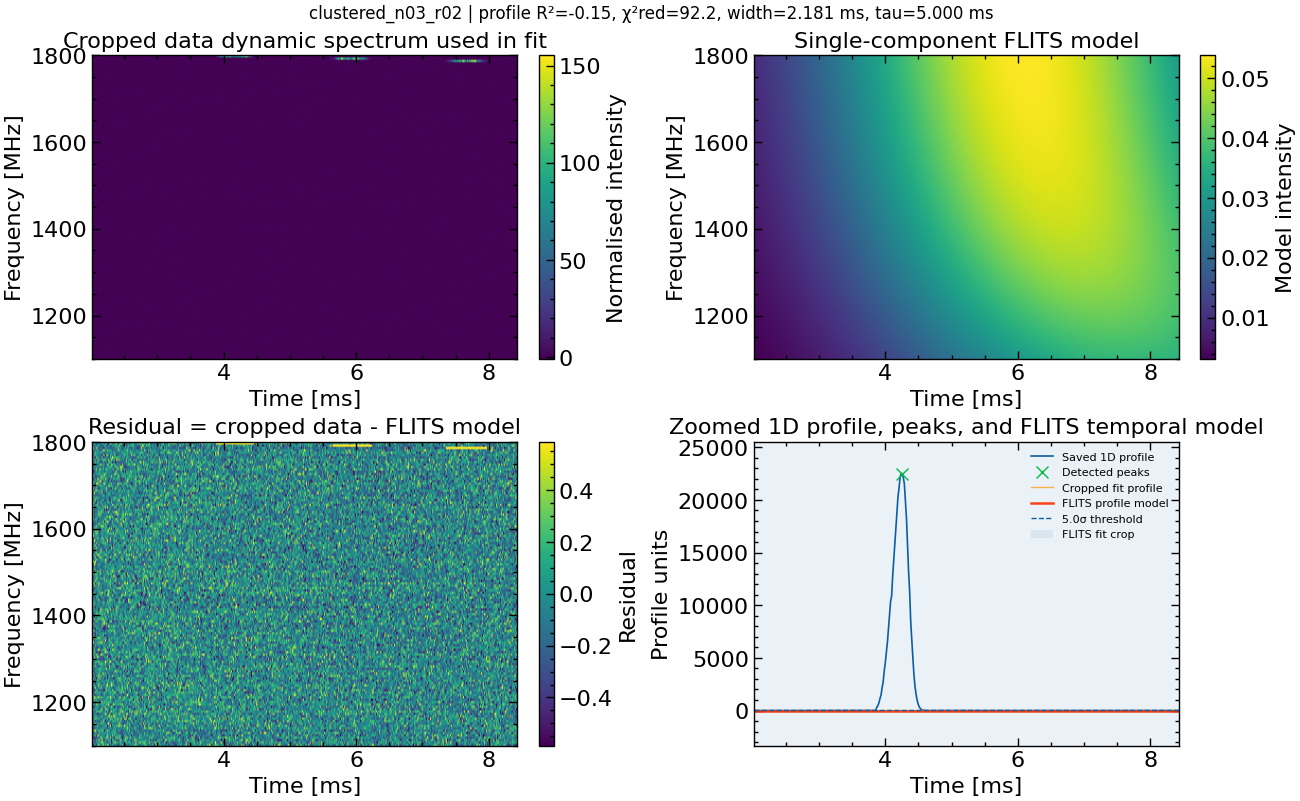

In [8]:

def plot_fit_summary(burst, products, fit_row=None, save_path=None):
    """
    Plot the cropped data/model/residual used by FLITS plus a zoomed 1D profile.

    The full saved burst file can be hundreds of ms long; the plotting window here is
    the same short window used for the FLITS fit.
    """
    t_full = np.asarray(burst["t_ms"], dtype=float)
    t_fit = np.asarray(products.get("t_ms_fit", t_full), dtype=float)
    freqs = products.get("freqs_mhz_sorted", burst["freqs_mhz"])

    profile_full = normalise_profile(burst["profile"])
    i0 = int(products.get("fit_i0", 0))
    i1 = int(products.get("fit_i1", len(t_full)))

    data_ft = products["data_ft"]
    model_ft = products["model_ft"]
    residual_ft = products["residual_ft"]
    profile_fit = products.get("profile_fit", np.nanmean(data_ft, axis=0))
    profile_model = products.get("profile_model", np.nanmean(model_ft, axis=0))

    fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

    extent = [t_fit.min(), t_fit.max(), np.nanmin(freqs), np.nanmax(freqs)]

    im0 = axes[0, 0].imshow(data_ft, aspect="auto", origin="lower", extent=extent)
    axes[0, 0].set_title("Cropped data dynamic spectrum used in fit")
    axes[0, 0].set_xlabel("Time [ms]")
    axes[0, 0].set_ylabel("Frequency [MHz]")
    fig.colorbar(im0, ax=axes[0, 0], label="Normalised intensity")

    im1 = axes[0, 1].imshow(model_ft, aspect="auto", origin="lower", extent=extent)
    axes[0, 1].set_title("Single-component FLITS model")
    axes[0, 1].set_xlabel("Time [ms]")
    axes[0, 1].set_ylabel("Frequency [MHz]")
    fig.colorbar(im1, ax=axes[0, 1], label="Model intensity")

    vmax = np.nanpercentile(np.abs(residual_ft), 99)
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    im2 = axes[1, 0].imshow(residual_ft, aspect="auto", origin="lower", extent=extent, vmin=-vmax, vmax=vmax)
    axes[1, 0].set_title("Residual = cropped data - FLITS model")
    axes[1, 0].set_xlabel("Time [ms]")
    axes[1, 0].set_ylabel("Frequency [MHz]")
    fig.colorbar(im2, ax=axes[1, 0], label="Residual")

    peaks, props = find_peaks(
        profile_full,
        height=PEAK_SIGMA_THRESHOLD,
        distance=max(1, int(round(MIN_PEAK_DISTANCE_MS / burst["tsamp_ms"])))
    )

    # Show the saved profile in the cropped/zoomed window.
    axes[1, 1].plot(t_full, profile_full, lw=1.2, label="Saved 1D profile")
    if len(peaks):
        in_view = (t_full[peaks] >= t_fit.min()) & (t_full[peaks] <= t_fit.max())
        axes[1, 1].plot(t_full[peaks][in_view], profile_full[peaks][in_view], "x", ms=8, label="Detected peaks")

    # Show the actual profile fitted by FLITS and the FLITS temporal model.
    axes[1, 1].plot(t_fit, profile_fit, lw=1.0, alpha=0.7, label="Cropped fit profile")
    axes[1, 1].plot(t_fit, profile_model, lw=1.8, alpha=0.9, label="FLITS profile model")

    axes[1, 1].axhline(PEAK_SIGMA_THRESHOLD, ls="--", lw=1, label=f"{PEAK_SIGMA_THRESHOLD:.1f}σ threshold")
    axes[1, 1].axvspan(t_fit.min(), t_fit.max(), alpha=0.08, label="FLITS fit crop")
    axes[1, 1].set_xlim(t_fit.min(), t_fit.max())

    # Robust y-limits in the zoom window.
    zoom_mask = (t_full >= t_fit.min()) & (t_full <= t_fit.max())
    yvals = profile_full[zoom_mask]
    if yvals.size and np.any(np.isfinite(yvals)):
        ylo, yhi = np.nanpercentile(yvals, [1, 99.5])
        if np.isfinite(ylo) and np.isfinite(yhi) and yhi > ylo:
            pad = 0.15 * (yhi - ylo)
            axes[1, 1].set_ylim(ylo - pad, yhi + pad)

    axes[1, 1].set_title("Zoomed 1D profile, peaks, and FLITS temporal model")
    axes[1, 1].set_xlabel("Time [ms]")
    axes[1, 1].set_ylabel("Profile units")
    axes[1, 1].legend(fontsize=8)

    title = burst["burst_id"]
    if fit_row is not None:
        title += (
            f" | profile R²={fit_row.get('flits_profile_r_squared', np.nan):.2f}"
            f", χ²red={fit_row.get('flits_profile_chi2_red', np.nan):.1f}"
            f", width={fit_row.get('flits_width_ms', np.nan):.3f} ms"
            f", tau={fit_row.get('flits_tau_1ghz_ms', np.nan):.3f} ms"
        )
    fig.suptitle(title)

    if save_path is not None:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    return fig

if burst_files:
    fig = plot_fit_summary(test_burst, test_products, test_fit, save_path=OUT_DIR / f"{test_burst['burst_id']}_fit_summary.png")
    plt.show()


## 7. Batch analysis of all saved bursts

This is the main analysis cell. It produces one row per burst containing:

- simulation parameters: `input_n_peaks`
- independent morphology metrics: `acf_sigma_ms`, `peak_count`, `peak_rate_per_ms`, `sep_cv`
- FLITS single-model fit metrics: `flits_width_ms`, `flits_tau_1ghz_ms`, `flits_chi2_red`, `flits_resid_rms`, `flits_quality_flag`

In [14]:
rows = []
failed = []

for i, path in enumerate(burst_files):
    try:
        burst = load_burst_npz(path)
        row = {
            "file": str(path),
            "burst_id": burst["burst_id"],
            "dm": burst["dm"],
            "nt": burst["ds_tf"].shape[0],
            "nf": burst["ds_tf"].shape[1],
        }

        # Truth metadata, if available.
        # Keep only science-relevant truth columns.  We intentionally do NOT save
        # bookkeeping columns such as used_will or will_method in the final table.
        truth = burst["truth"]
        if "input_n_peaks" in truth:
            row["input_n_peaks"] = truth["input_n_peaks"]

        # Profile morphology metrics
        row.update(profile_metrics(burst["profile"], burst["tsamp_ms"], burst["burst_id"]))

        # FLITS fit metrics
        fit_row, products = fit_single_flits_model(burst, fit_dm=FIT_DM, tau_alpha=TAU_ALPHA)
        row.update(fit_row)

        rows.append(row)
        if (i + 1) % 5 == 0 or i == 0:
            print(f"Done {i+1}/{len(burst_files)}")

    except Exception as e:
        failed.append({"file": str(path), "error": repr(e)})
        print("FAILED", path, repr(e))

results = pd.DataFrame(rows)
failed_df = pd.DataFrame(failed)

# Remove non-science bookkeeping columns if they came from older cached rows.
for col in ["used_will", "will_method"]:
    if col in results.columns:
        results = results.drop(columns=[col])

results_path = OUT_DIR / "flits_microshot_results.csv"
failed_path = OUT_DIR / "flits_microshot_failed.csv"
results.to_csv(results_path, index=False)
failed_df.to_csv(failed_path, index=False)

print("Saved:", results_path)
print("Failed:", len(failed_df), "saved to", failed_path)

display(results.head())

/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5146.
  res = hypotest_fun_out(*samples, **kwds)


Done 1/26


/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5189.
  res = hypotest_fun_out(*samples, **kwds)
/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5172.
  res = hypotest_fun_out(*samples, **kwds)
/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5042.
  res = hypotest_fun_out(*samples, **kwds)
/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5159.
  res = hypotest_fun_out(*s

Done 5/26


/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5144.
  res = hypotest_fun_out(*samples, **kwds)
/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5376.
  res = hypotest_fun_out(*samples, **kwds)
/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5056.
  res = hypotest_fun_out(*samples, **kwds)
/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5081.
  res = hypotest_fun_out(*s

...

Done 20/26


/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5133.
  res = hypotest_fun_out(*samples, **kwds)
/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5132.
  res = hypotest_fun_out(*samples, **kwds)
/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5196.
  res = hypotest_fun_out(*samples, **kwds)
/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5043.
  res = hypotest_fun_out(*s

Done 25/26
Saved: flits_direct_results_2/flits_microshot_results.csv
Failed: 0 saved to flits_direct_results_2/flits_microshot_failed.csv


/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5212.
  res = hypotest_fun_out(*samples, **kwds)


,file,burst_id,dm,nt,nf,input_n_peaks,tsamp_ms,acf_sigma_ms,acf_resid_rms,peak_count,...,flits_r_squared,flits_durbin_watson,flits_residual_bias,flits_residual_bias_sigma,flits_residual_normality_pvalue,flits_quality_flag,flits_profile_chi2_red,flits_profile_r_squared,flits_profile_resid_rms,flits_profile_quality_flag
0,will_flits_microshot_package/will_microshot_ou...,clustered_n03_r02,220.0,30289,128,3,0.016,0.162760,0.001529,1,...,-0.000783,0.145574,0.112892,7.258971,1.022080e-95,FAIL,92.158329,-0.146245,0.294919,FAIL
1,will_flits_microshot_package/will_microshot_ou...,clustered_n03_r04,220.0,30289,128,3,0.016,0.165682,0.151010,4,...,-0.000875,0.108512,0.124137,9.479651,4.624744e-96,FAIL,165.639812,-0.148826,0.280061,FAIL
2,will_flits_microshot_package/will_microshot_ou...,clustered_n03_r05,220.0,30289,128,3,0.016,0.187399,0.016875,2,...,0.001505,0.078105,0.074195,5.687533,6.485018e-96,FAIL,96.328118,0.234325,0.208241,MARGINAL
3,will_flits_microshot_package/will_microshot_ou...,clustered_n06_r02,220.0,30289,128,6,0.016,0.320341,0.190274,6,...,-0.000588,0.188822,0.105184,9.222143,4.314384e-95,FAIL,237.991969,-0.122406,0.275020,FAIL
4,will_flits_microshot_package/will_microshot_ou...,clustered_n06_r03,220.0,30289,128,6,0.016,0.168791,0.001878,2,...,0.001394,0.099252,0.082563,5.793656,1.009623e-95,FAIL,84.205857,0.173665,0.234826,FAIL


## 8. First diagnostic plots

The main thing to look for is whether bursts with similar `acf_sigma_ms` have different:

- `peak_count`
- `peak_rate_per_ms`
- `sep_cv`
- `flits_chi2_red`
- `flits_resid_rms`


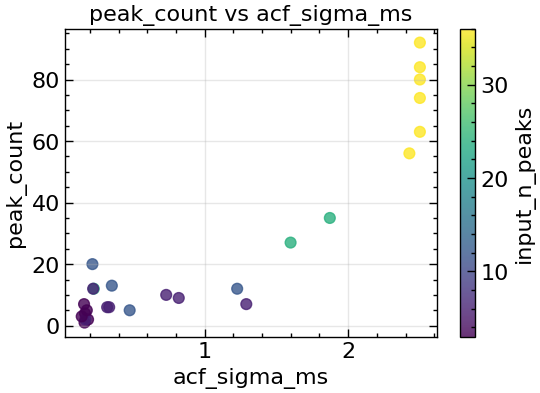

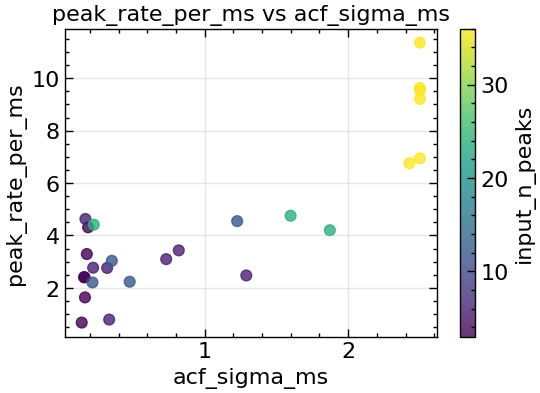

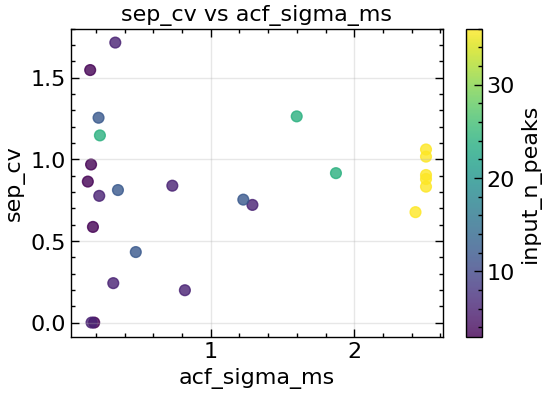

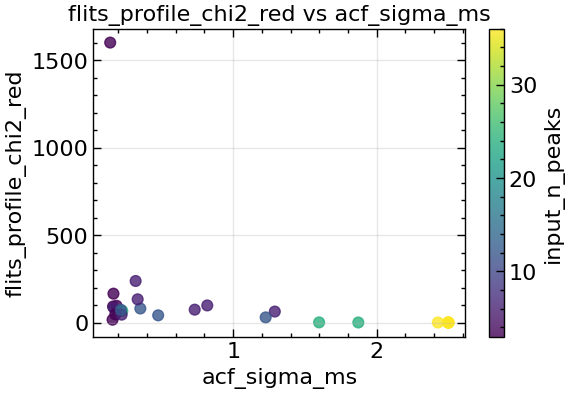

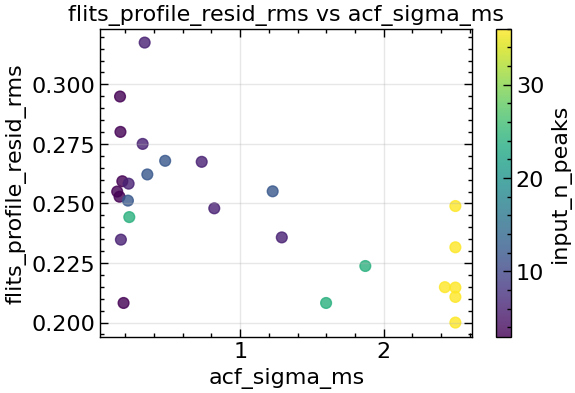

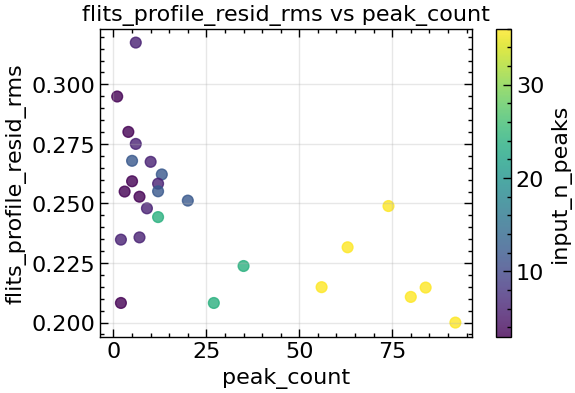

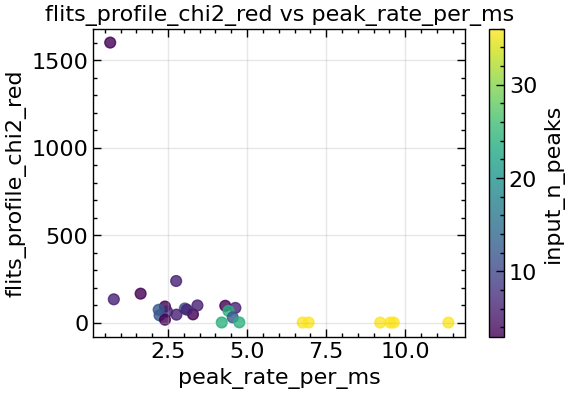

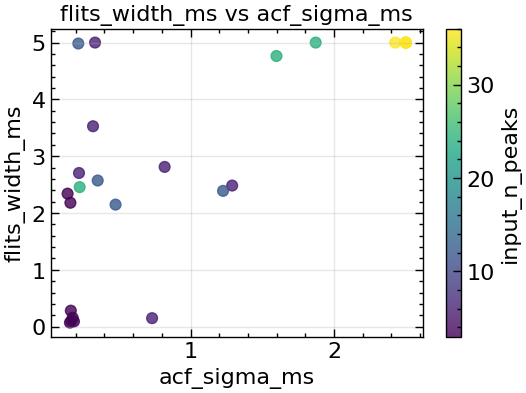

In [10]:
def safe_scatter(df, x, y, color_col=None, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure

    plot_df = df[[x, y] + ([color_col] if color_col and color_col in df.columns else [])].replace([np.inf, -np.inf], np.nan).dropna()
    if plot_df.empty:
        ax.text(0.5, 0.5, f"No finite data for {x} vs {y}", ha="center", va="center", transform=ax.transAxes)
        return fig, ax

    if color_col and color_col in plot_df.columns:
        sc = ax.scatter(plot_df[x], plot_df[y], c=plot_df[color_col], s=60, alpha=0.8)
        fig.colorbar(sc, ax=ax, label=color_col)
    else:
        ax.scatter(plot_df[x], plot_df[y], s=60, alpha=0.8)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title or f"{y} vs {x}")
    ax.grid(alpha=0.3)
    return fig, ax

if not results.empty:
    color_col = "input_n_peaks" if "input_n_peaks" in results.columns else None

    for x, y in [
        ("acf_sigma_ms", "peak_count"),
        ("acf_sigma_ms", "peak_rate_per_ms"),
        ("acf_sigma_ms", "sep_cv"),
        ("acf_sigma_ms", "flits_profile_chi2_red"),
        ("acf_sigma_ms", "flits_profile_resid_rms"),
        ("peak_count", "flits_profile_resid_rms"),
        ("peak_rate_per_ms", "flits_profile_chi2_red"),
        ("acf_sigma_ms", "flits_width_ms"),
    ]:
        if x in results.columns and y in results.columns:
            fig, ax = safe_scatter(results, x, y, color_col=color_col)
            fig.savefig(OUT_DIR / f"scatter_{x}_vs_{y}.png", dpi=160, bbox_inches="tight")
            plt.show()

## 9. Select bursts with similar timescale but different complexity

This step selects a group of bursts with similar `acf_sigma_ms` but a large spread in a chosen complexity metric.

Here I use `peak_count` and `flits_resid_rms` as complexity metrics.

In [11]:
def select_similar_timescale_different_metric(
    df,
    tau_col="acf_sigma_ms",
    metric_col="peak_count",
    tolerance_fraction=0.20,
    min_group_size=3,
):
    work = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[tau_col, metric_col]).copy()
    if work.empty:
        return work
    work = work.sort_values(tau_col).reset_index(drop=True)

    best = None
    best_score = -np.inf

    taus = work[tau_col].to_numpy(float)
    for i, tau0 in enumerate(taus):
        if not np.isfinite(tau0) or tau0 <= 0:
            continue
        mask = np.abs(taus - tau0) <= tolerance_fraction * tau0
        group = work.loc[mask].copy()
        if len(group) < min_group_size:
            continue
        metric_range = group[metric_col].max() - group[metric_col].min()
        tau_spread = group[tau_col].max() - group[tau_col].min()
        score = metric_range / (tau_spread + 1e-9)
        if score > best_score:
            best = group
            best_score = score

    if best is None:
        return pd.DataFrame(columns=df.columns)
    return best.sort_values(metric_col)

selected_peak_count = select_similar_timescale_different_metric(
    results,
    tau_col="acf_sigma_ms",
    metric_col="peak_count",
    tolerance_fraction=0.20,
    min_group_size=3,
)

selected_peak_rate = select_similar_timescale_different_metric(
    results,
    tau_col="acf_sigma_ms",
    metric_col="peak_rate_per_ms",
    tolerance_fraction=0.20,
    min_group_size=3,
)

selected_flits_resid = select_similar_timescale_different_metric(
    results,
    tau_col="acf_sigma_ms",
    metric_col="flits_profile_resid_rms",
    tolerance_fraction=0.20,
    min_group_size=3,
)

selected_peak_count.to_csv(OUT_DIR / "selected_similar_tau_different_peak_count.csv", index=False)
selected_peak_rate.to_csv(OUT_DIR / "selected_similar_tau_different_peak_rate.csv", index=False)
selected_flits_resid.to_csv(OUT_DIR / "selected_similar_tau_different_flits_profile_residual.csv", index=False)

print("Selected by peak_count:")
display(selected_peak_count[[c for c in ["burst_id", "acf_sigma_ms", "peak_count", "peak_rate_per_ms", "sep_cv", "flits_profile_chi2_red", "flits_profile_resid_rms", "flits_profile_quality_flag"] if c in selected_peak_count.columns]])

print("Selected by FLITS residual RMS:")
display(selected_flits_resid[[c for c in ["burst_id", "acf_sigma_ms", "peak_count", "peak_rate_per_ms", "sep_cv", "flits_profile_chi2_red", "flits_profile_resid_rms", "flits_profile_quality_flag"] if c in selected_flits_resid.columns]])

Selected by peak_count:


,burst_id,acf_sigma_ms,peak_count,peak_rate_per_ms,sep_cv,flits_profile_chi2_red,flits_profile_resid_rms,flits_profile_quality_flag
20,sparse_n36_r00,2.426767,56,6.756757,0.676365,0.783629,0.214874,MARGINAL
25,sparse_n36_r03,2.500000,63,6.944444,1.060285,0.824945,0.231619,MARGINAL
22,sparse_n36_r05,2.500000,74,9.635417,1.016346,0.817281,0.248937,FAIL
23,quasiperiodic_n36_r03,2.500000,80,9.208103,0.879344,0.387460,0.210781,MARGINAL
24,quasiperiodic_n36_r02,2.500000,84,9.528131,0.832495,0.495446,0.214706,MARGINAL
21,quasiperiodic_n36_r00,2.500000,92,11.363636,0.903850,0.567852,0.200003,MARGINAL


Selected by FLITS residual RMS:


,burst_id,acf_sigma_ms,peak_count,peak_rate_per_ms,sep_cv,flits_profile_chi2_red,flits_profile_resid_rms,flits_profile_quality_flag
4,clustered_n06_r03,0.168791,2,4.629630,0.000000,84.205857,0.234826,FAIL
1,moderate_n03_r00,0.159405,7,2.403846,1.546712,16.860754,0.252845,FAIL
0,sparse_n03_r03,0.143024,3,0.672043,0.863636,1600.244265,0.255017,FAIL
3,clustered_n03_r04,0.165682,4,1.633987,0.968147,165.639812,0.280061,FAIL
2,clustered_n03_r02,0.162760,1,2.403846,NaN,92.158329,0.294919,FAIL


## 10. Plot the selected lowest-complexity and highest-complexity bursts from first group


Low peak-count selected burst: sparse_n36_r00


/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5196.
  res = hypotest_fun_out(*samples, **kwds)


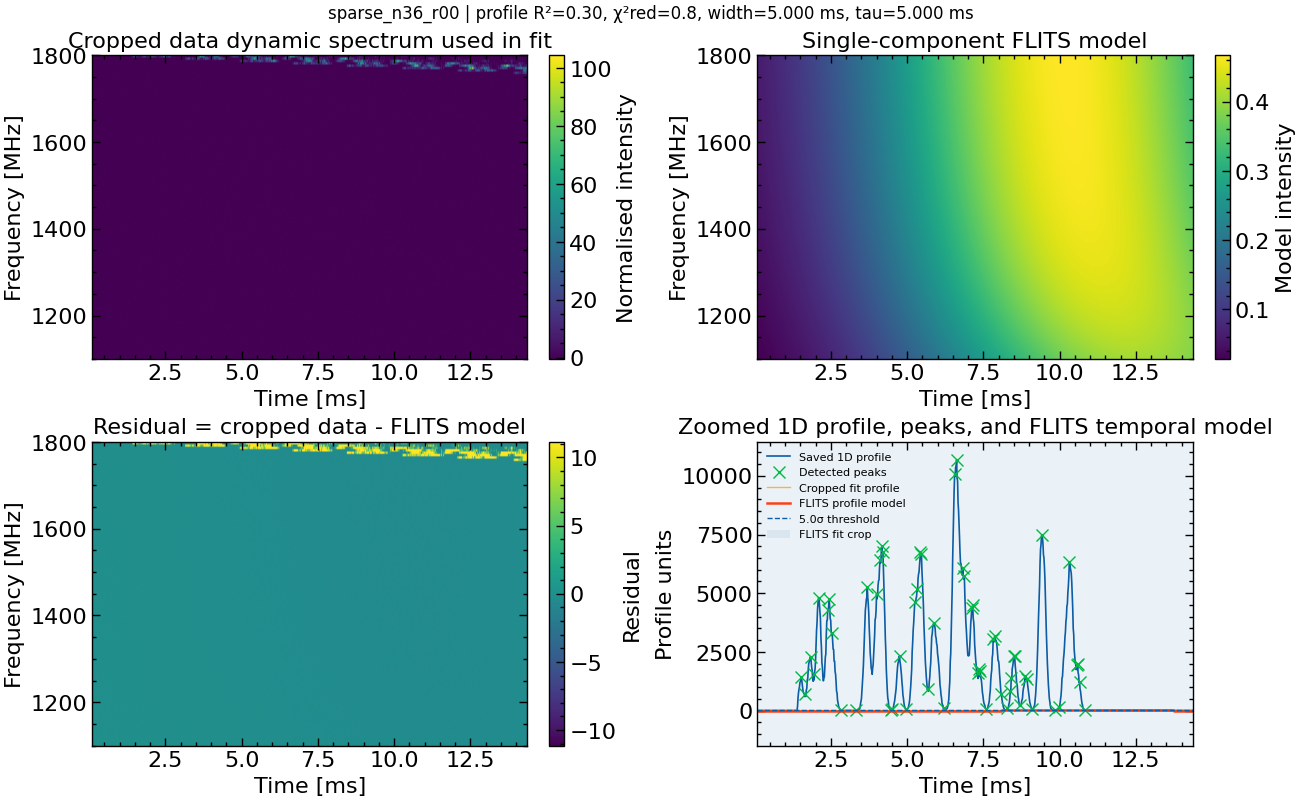

High peak-count selected burst: quasiperiodic_n36_r00


/home/giannis/miniforge/envs/astrovaria/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5126.
  res = hypotest_fun_out(*samples, **kwds)


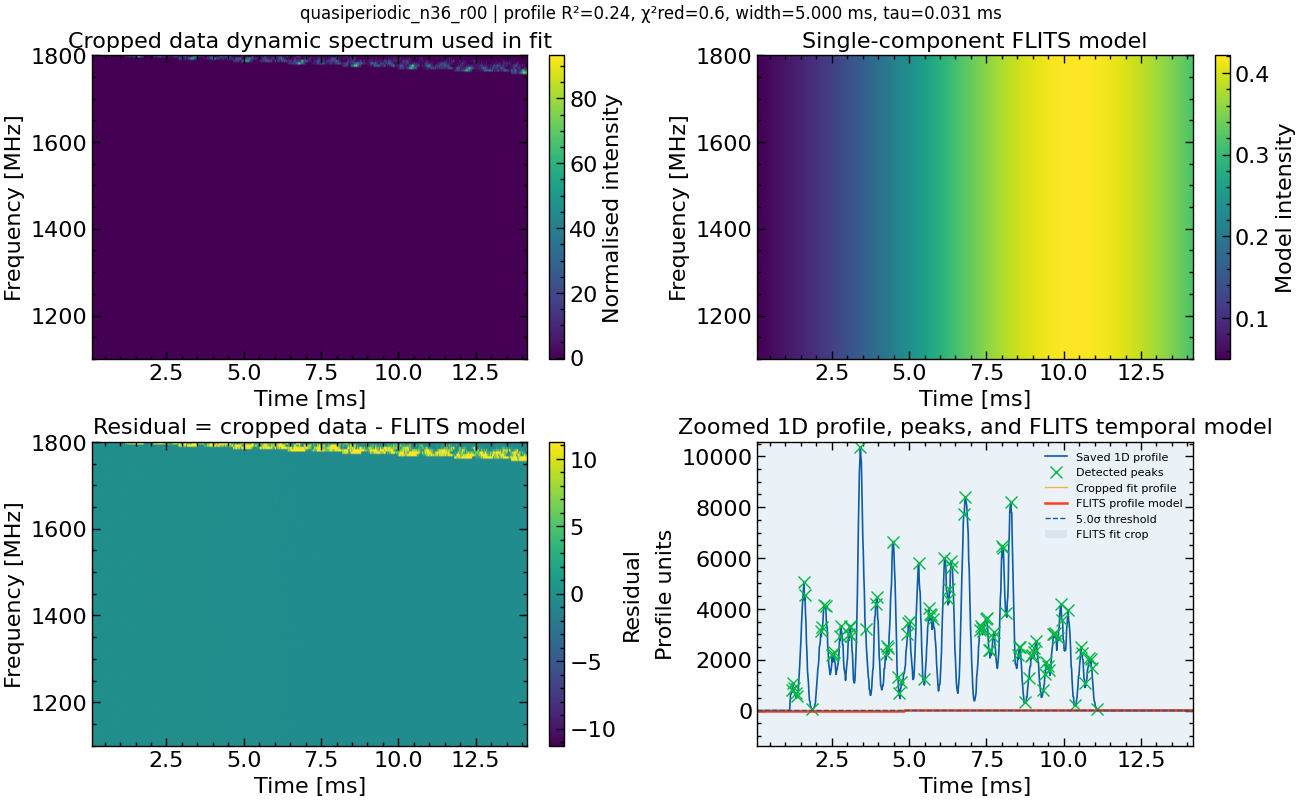

In [12]:
def refit_and_plot_from_row(row, suffix="selected"):
    burst = load_burst_npz(row["file"])
    fit_row, products = fit_single_flits_model(burst, fit_dm=FIT_DM, tau_alpha=TAU_ALPHA)
    safe_id = str(burst["burst_id"]).replace("/", "_").replace(" ", "_")
    fig = plot_fit_summary(
        burst,
        products,
        fit_row,
        save_path=OUT_DIR / f"{safe_id}_{suffix}_fit_summary.png",
    )
    return fig

if not selected_peak_count.empty:
    low = selected_peak_count.iloc[0]
    high = selected_peak_count.iloc[-1]

    print("Low peak-count selected burst:", low["burst_id"])
    fig = refit_and_plot_from_row(low, suffix="low_peak_count")
    plt.show()

    print("High peak-count selected burst:", high["burst_id"])
    fig = refit_and_plot_from_row(high, suffix="high_peak_count")
    plt.show()
else:
    print("No selected group found. Try increasing tolerance_fraction or reducing min_group_size.")

## 11. Comparison of FLITS recovered width to ACF timescale


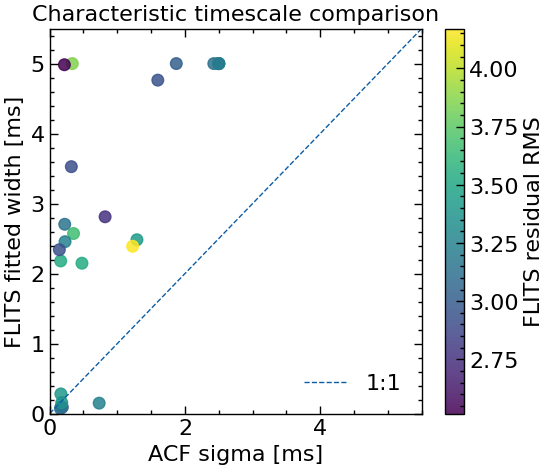

In [13]:
if not results.empty and {"acf_sigma_ms", "flits_width_ms", "flits_resid_rms"}.issubset(results.columns):
    plot_df = results.replace([np.inf, -np.inf], np.nan).dropna(subset=["acf_sigma_ms", "flits_width_ms", "flits_resid_rms"])
    if not plot_df.empty:
        fig, ax = plt.subplots(figsize=(6, 5))
        sc = ax.scatter(plot_df["acf_sigma_ms"], plot_df["flits_width_ms"], c=plot_df["flits_resid_rms"], s=70, alpha=0.85)
        lim_max = 1.1 * np.nanmax([plot_df["acf_sigma_ms"].max(), plot_df["flits_width_ms"].max()])
        ax.plot([0, lim_max], [0, lim_max], ls="--", lw=1, label="1:1")
        ax.set_xlim(0, lim_max)
        ax.set_ylim(0, lim_max)
        ax.set_xlabel("ACF sigma [ms]")
        ax.set_ylabel("FLITS fitted width [ms]")
        ax.set_title("Characteristic timescale comparison")
        ax.legend()
        fig.colorbar(sc, ax=ax, label="FLITS residual RMS")
        fig.savefig(OUT_DIR / "acf_sigma_vs_flits_width_colored_by_residual.png", dpi=160, bbox_inches="tight")
        plt.show()